### Figure 1 D + E & Figure 4 A + B + E

In [1]:
### define setting to indicate raw data in saved files
database <- "MGnify" # MGnify / IGC / Qin
grouping <- "Groups" # Groups / Subgroups
new_discovery_study <- "Werner" # ValdesMas / Werner
file_prefix <- paste(database,"_",grouping,"_",new_discovery_study,"_", sep ="")
print(file_prefix)

[1] "MGnify_Groups_Werner_"


In [3]:
library(readxl)
library(tidyverse)
library(ggrepel)
library(ggtext)
library(ggExtra)
library(vegan)
library(glue)

Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'tibble' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'tidyr' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'readr' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'purrr' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'dplyr' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'stringr' wurde unter R Version 4.4.3 erstellt"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ U

In [4]:
### load sample meta data
metadata <- read_excel("../SupplementaryFile1(WernerDiscovery)-Revision.xlsx") %>%
  column_to_rownames(var = "SampleID") %>%
  t()%>%
  as.data.frame() %>%
  ### for standard variance analysis:
  filter(study == "Lehmann" | study == "Henry" | study == "Thuy-Boun" | study == "Lloyd-Price" | study == "Werner") %>%

  ### for Leave-One-Dataset-Out analysis'
  #filter(study == "Werner" | study == "Lloyd-Price" | study == "Lehmann" | study == "Thuy-Boun") %>%
  #filter(study == "Henry" | study == "Werner" | study == "Lehmann" | study == "Thuy-Boun") %>%
  #filter(study == "Henry" | study == "Lloyd-Price" | study == "Werner" | study == "Thuy-Boun") %>%
  #filter(study == "Henry" | study == "Lloyd-Price" | study == "Lehmann" | study == "Werner") %>%
  #filter(study == "Henry" | study == "Lloyd-Price" | study == "Lehmann" | study == "Thuy-Boun") %>%
  
  filter(UseCase == "BiomarkerDiscovery") %>%
  # filter for comparision of all IBD patients vs healthy individuals
  filter(disease == "normal" | disease == "UC" | disease == "CD") %>%
  
  # filter for comparision of CD patients vs healthy individuals (Figure 3)
  #filter(disease == "normal" | disease == "CD") %>%
  
  # filter for comparision of UC patients vs healthy individuals (Figure 3)
  #filter(disease == "normal" | disease == "UC") %>%
  
  # filter for comparision of UC patients vs CD patients (Figure 3)
  #filter(disease == "UC" | disease == "CD") %>%

   as.data.frame() %>% 
    rownames_to_column(var = "ID")

metadata$ID <- gsub("\\.", "\\_", metadata$ID)
metadata$ID <- gsub("\\-", "\\_", metadata$ID)


In [5]:
filename <- paste("../", file_prefix,"shared_metaproteins(discovery_studies_normalized_MMUPHin_corrected).csv", sep="")
shared_metaproteins <- read.delim(filename,check.names = FALSE, header = TRUE, sep = ",")  
rownames(shared_metaproteins) <- shared_metaproteins[,1]
#remove first column from data frame
shared_metaproteins <- shared_metaproteins[,-1]
head(shared_metaproteins)

,20190107_08_T05F_env,20190107_20_T08F_env,20190111_30_T03F_env,20190111_36_T01F_env,20190114_58_T02F_env,20190114_62_T07F_env,20190117_70_T04F_env,20190117_74_T06F_env,160618_SM_A47RW_38,160829_SM_9ZE92_260,⋯,160923_SM_6XTTJ_427,160923_SM_71T47_393,160928_SM_7BCZJ_397,160930_SM_6SSN7_440,160930_SM_71T3Q_395,161004_SM_9W3AR_549,161011_SM_5QVZH_531,161011_SM_9KOQA_562,161017_SM_69UN3_535,161017_SM_7LSOC_583
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.0002878818,0.0001411053,0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0001444328,0.0000000000,0.0005992001,⋯,0.0000000000,0.0005309340,0.0002130852,0.0001351128,0.0001752987,0,0.0005825938,0.0005469647,0.0003087128,0.0006051367
2,0.0000000000,0.0000000000,0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,⋯,0.0001724232,0.0002303419,0.0000000000,0.0000000000,0.0002779334,0,0.0003371950,0.0009524888,0.0000000000,0.0005259024
3,0.0000000000,0.0000000000,0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0001579908,0.0000000000,⋯,0.0000000000,0.0007463320,0.0000000000,0.0000000000,0.0001703706,0,0.0003826290,0.0005246271,0.0001584330,0.0008500215
5,0.0000000000,0.0000000000,0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,⋯,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0002670678,0,0.0000000000,0.0008748698,0.0000000000,0.0000000000
7,0.0000000000,0.0001298196,0,0.0001337496,0.0001369866,0.0001342629,0.0001344626,0.0000000000,0.0000000000,0.0000000000,⋯,0.0001717536,0.0002280061,0.0000000000,0.0000000000,0.0001421472,0,0.0001701203,0.0004603707,0.0001322428,0.0000000000
8,0.0001495954,0.0001412789,0,0.0001434965,0.0001458893,0.0000000000,0.0001442865,0.0000000000,0.0000000000,0.0001964593,⋯,0.0001759423,0.0000000000,0.0000000000,0.0000000000,0.0003061562,0,0.0001743775,0.0005910124,0.0001293740,0.0000000000


In [6]:
### for matching of sample IDs
names(shared_metaproteins) <- sub("^quant_[^_]+_(.*?)_mgf_.*$", "\\1", names(shared_metaproteins))
names(shared_metaproteins) <- sub("^quant_F[^_]+_(.*)_\\s*$", "\\1", names(shared_metaproteins))
### for qin dataset:
#names(shared_metaproteins) <- sub("^[^_]+_(.*)_[^_]+$", "\\1", names(shared_metaproteins))
names(shared_metaproteins) <- gsub("\\.", "\\_", names(shared_metaproteins))
names(shared_metaproteins) <- gsub("\\-", "\\_", names(shared_metaproteins))
names(shared_metaproteins) <- gsub("\\_480Ex2", "\\1", names(shared_metaproteins))

### Check dimension
print(dim(shared_metaproteins)) 
head((shared_metaproteins)) 

[1] 1789  132


,20190107_08_T05F_env,20190107_20_T08F_env,20190111_30_T03F_env,20190111_36_T01F_env,20190114_58_T02F_env,20190114_62_T07F_env,20190117_70_T04F_env,20190117_74_T06F_env,160618_SM_A47RW_38,160829_SM_9ZE92_260,⋯,160923_SM_6XTTJ_427,160923_SM_71T47_393,160928_SM_7BCZJ_397,160930_SM_6SSN7_440,160930_SM_71T3Q_395,161004_SM_9W3AR_549,161011_SM_5QVZH_531,161011_SM_9KOQA_562,161017_SM_69UN3_535,161017_SM_7LSOC_583
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.0002878818,0.0001411053,0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0001444328,0.0000000000,0.0005992001,⋯,0.0000000000,0.0005309340,0.0002130852,0.0001351128,0.0001752987,0,0.0005825938,0.0005469647,0.0003087128,0.0006051367
2,0.0000000000,0.0000000000,0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,⋯,0.0001724232,0.0002303419,0.0000000000,0.0000000000,0.0002779334,0,0.0003371950,0.0009524888,0.0000000000,0.0005259024
3,0.0000000000,0.0000000000,0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0001579908,0.0000000000,⋯,0.0000000000,0.0007463320,0.0000000000,0.0000000000,0.0001703706,0,0.0003826290,0.0005246271,0.0001584330,0.0008500215
5,0.0000000000,0.0000000000,0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,⋯,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0002670678,0,0.0000000000,0.0008748698,0.0000000000,0.0000000000
7,0.0000000000,0.0001298196,0,0.0001337496,0.0001369866,0.0001342629,0.0001344626,0.0000000000,0.0000000000,0.0000000000,⋯,0.0001717536,0.0002280061,0.0000000000,0.0000000000,0.0001421472,0,0.0001701203,0.0004603707,0.0001322428,0.0000000000
8,0.0001495954,0.0001412789,0,0.0001434965,0.0001458893,0.0000000000,0.0001442865,0.0000000000,0.0000000000,0.0001964593,⋯,0.0001759423,0.0000000000,0.0000000000,0.0000000000,0.0003061562,0,0.0001743775,0.0005910124,0.0001293740,0.0000000000


In [7]:
#### filter columns to select only samples that are goal of this analysis
filter_meta <- shared_metaproteins %>% 
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "ID") %>%
  inner_join(metadata, ., by = "ID") %>%
  select(-(2:5)) %>% # 2:8
  column_to_rownames(var = "ID") %>%
  t() %>%
  as.data.frame() # %>%
filter_meta

# remove rows from metadata where the sample is not in measurement data
setdiff(colnames(filter_meta), metadata$ID)
setdiff(metadata$ID, colnames(filter_meta))

length(metadata$ID)
length(colnames(filter_meta))

,Seq85789,Seq86293,Seq86298,Seq86307,Seq86317,Seq85784,Seq85785,Seq86296,Seq86299,Seq86304,⋯,UC1,UC11,UC15,UC2,UC23F,UC4,UC5,UC6,UC8,UC9
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.0007918705,1.275677e-04,3.459039e-04,3.952894e-04,5.909852e-04,1.371341e-04,0.0000000000,0.000000e+00,1.784314e-04,3.923860e-04,⋯,0.0004151302,0.0005963596,0.0000000000,0.0004165958,0.0005493664,0.0000000000,0.0002448566,0.0018149599,0.0000000000,0.0003521877
2,0.0003521320,1.206961e-04,2.893993e-04,1.866354e-04,3.940324e-04,1.400854e-04,0.0000000000,0.000000e+00,1.451080e-04,0.000000e+00,⋯,0.0002186705,0.0003094503,0.0000000000,0.0001919270,0.0003163235,0.0000000000,0.0000000000,0.0004318641,0.0000000000,0.0000000000
3,0.0005556043,1.139760e-04,2.481105e-04,5.108766e-04,5.961837e-04,0.000000e+00,0.0000000000,0.000000e+00,1.564641e-04,2.369399e-04,⋯,0.0001224650,0.0003204410,0.0000000000,0.0000000000,0.0004593903,0.0000000000,0.0000000000,0.0010998500,0.0000000000,0.0000000000
5,0.0000000000,0.000000e+00,0.000000e+00,0.000000e+00,9.807469e-05,0.000000e+00,0.0000000000,0.000000e+00,0.000000e+00,0.000000e+00,⋯,0.0000000000,0.0000837621,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0004686041,0.0000000000,0.0000000000
7,0.0004886620,0.000000e+00,0.000000e+00,8.496042e-05,2.574468e-04,0.000000e+00,0.0000000000,0.000000e+00,6.392063e-05,8.942072e-05,⋯,0.0000000000,0.0001495278,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0005249370,0.0000000000,0.0000000000
8,0.0005122793,9.297877e-05,1.088680e-04,9.734905e-05,3.805182e-04,0.000000e+00,0.0000000000,0.000000e+00,7.404615e-05,2.272850e-04,⋯,0.0000000000,0.0002627110,0.0000000000,0.0001505839,0.0002223239,0.0001649614,0.0003282991,0.0007154977,0.0000000000,0.0001221583
9,0.0008832774,2.932701e-04,5.739130e-04,5.215185e-04,9.387159e-04,9.250791e-04,0.0009410022,0.000000e+00,2.354612e-04,4.228599e-04,⋯,0.0008909422,0.0009495570,0.0001764012,0.0006837942,0.0008581118,0.0007489359,0.0011009357,0.0026885433,0.0008213612,0.0006608192
10,0.0005181773,3.198211e-04,2.682639e-04,3.069226e-04,5.481318e-04,8.061373e-05,0.0005863751,3.632087e-05,2.364283e-04,2.738235e-04,⋯,0.0001334822,0.0005820856,0.0000000000,0.0002065107,0.0002409399,0.0000000000,0.0005145071,0.0013954230,0.0003965971,0.0002333313
11,0.0005199178,1.252866e-04,1.581729e-04,2.661108e-04,1.925390e-04,1.948937e-04,0.0000000000,0.000000e+00,1.042098e-04,2.741069e-04,⋯,0.0003027712,0.0006294594,0.0000000000,0.0001937458,0.0000000000,0.0000000000,0.0000000000,0.0004150206,0.0000000000,0.0001304738


character(0)

character(0)

[1] 132

[1] 132

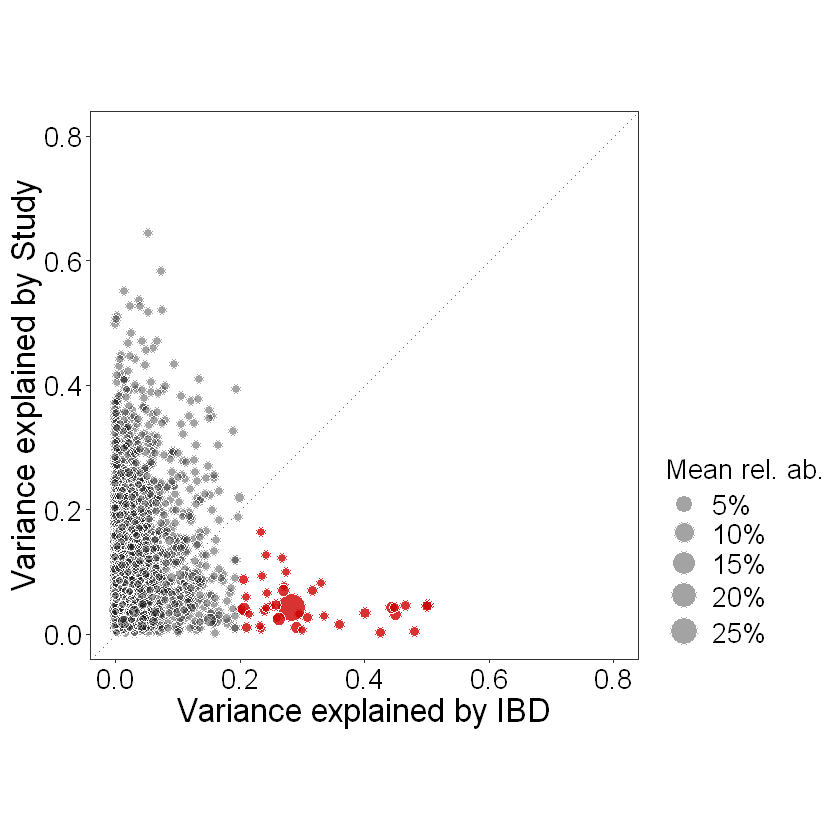

In [8]:
### METAPROTEINS ###
### Input data: metaproteins identified in all studies before / after batch effect correction

######### new
rel_abund <-filter_meta # shared_metaproteins / filter_meta
# variance analysis for IBD and study

feat.conf <- rel_abund
label.conf <- metadata$condition# metadata$condition or metadata$disease --> control / diseased --> for UC vs CD, this has to be changend to "disease" and UC/UCr/UCa have to be united
#label.conf <- metadata$disease
names(label.conf) <- colnames(feat.conf)
study <- as.factor(metadata$study)
names(study) <- colnames(feat.conf)

var.label <- vapply(rownames(feat.conf), FUN = function(x) {
  x <- feat.conf[x, ]
  x <- rank(x)/length(x)
  ss.tot <- sum((x - mean(x, na.rm = TRUE))^2)/length(x)
  ss.o.i <- sum(vapply(unique(label.conf), function(s) {
    sum((x[label.conf == s] - mean(x[label.conf == s], na.rm = TRUE))^2)
  }, FUN.VALUE = double(1)))/length(x)
  return(1 - ss.o.i/ss.tot)
}, FUN.VALUE = double(1))

if (any(is.infinite(var.label))) {
  var.label[is.infinite(var.label)] <- NA
}

var.batch <- vapply(rownames(feat.conf), FUN = function(x) {
  x <- feat.conf[x, na.omit(names(study))]
  x <- rank(x)/length(x)
  ss.tot <- sum((x - mean(x, na.rm = TRUE))^2)/length(x)
  ss.o.i <- sum(vapply(levels(study), function(s) {
    sum((x[study == s] - mean(x[study == s], na.rm = TRUE))^2)
  }, FUN.VALUE = double(1)))/length(x)
  return(1 - ss.o.i/ss.tot)
}, FUN.VALUE = double(1))

if (any(is.infinite(var.batch))) {
  var.batch[is.infinite(var.batch)] <- NA
}


df.plot <- tibble(label = var.label, batch = var.batch, species=names(var.label))

df.plot$mean <- rowMeans(feat.conf * 100, na.rm = TRUE)

df.plot %>% 
  ggplot(aes(x = label, y = batch, size = mean)) + 
  
  geom_point(data = subset(df.plot, label >= 0.2 & label > batch),
             aes(x = label, y = batch, size = mean),
             shape = 21, show.legend = FALSE, fill = alpha("red3", 0.8), color = "white", stroke = 0.2) +
  
  geom_point(data = subset(df.plot, label < 0.2 | label < batch), 
             aes(x = label, y = batch, size = mean), 
             shape = 21, show.legend = TRUE, fill = alpha("grey10", 0.4), color = "white", stroke = 0.2) +
  
  labs(y = "Variance explained by Study", x = "Variance explained by IBD", size = "Mean rel. ab.") +
  theme_bw() +
  theme(aspect.ratio = 1, 
        legend.position = "right",  
        legend.direction = "vertical",
        legend.box = "vertical",
        legend.justification = "bottom",
        axis.text = element_text(color = "black", size = 16),
        axis.title=element_text(size=20),
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 16),
        panel.grid = element_blank() ) + 
  scale_size_continuous(range = c(2.5, 8), labels = scales::percent_format(scale = 1)) + 
  xlim(0, 0.8) + 
  ylim(0, 0.8) + 
  geom_abline(intercept = 0, slope = 1, col = 'grey40', linetype = 3)

  ## save plot
  filename <- paste(file_prefix, "variance_explained_shared_MMUPHin_corrected_Werner.png", sep="") 
  ggsave(filename, width = 13, height = 13, units = "cm", dpi = 1000)


In [215]:
# filter for proteins that have a higher variance explained by IBD than study and a variance explained by study <= 0.20 
filtered_df.plot <- df.plot %>%
  filter(label >= 0.20, label > batch) %>%
  select(1:4)
# save these potential biomarkers for further analysis
filename <- paste(file_prefix, "variance_explained_shared_MMUPHin_corrected.csv", sep="")
write.csv(filtered_df.plot, file = filename, row.names = FALSE)